# Молекулярная динамика отобранных скаффолдов

Проверка ранжирования модели способом, независимым от оракула: скаффолды RFdiffusion,
отобранные и отбракованные нашей сетью, прогоняются в явном растворителе, и сравнивается
их поведение.

Смысл именно в независимости. Все метрики в docs/05 и docs/08 опираются на истинный
scRMSD, а это мнение ESMFold — той же нейросетевой семьи, что и оцениваемые генераторы.
Силовое поле не знает ни про PDB-статистику обучающей выборки, ни про предпочтения
ProteinMPNN. Совпадение двух оценок — довод, что модель ловит физику, а не причуды оракула.

Тетрадь содержит весь разбор траекторий целиком: подготовка и счёт делаются скриптами
`md/*.sh` (это часы GPU), всё остальное — здесь.

Текстовая версия с выводами: `docs/10-molekulyarnaya-dinamika.md`.

In [1]:
# Подъём до корня репозитория (тетрадь открывается в notebooks/)
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
print(os.getcwd())

/home/pc/PycharmProjects/BbValidator


In [2]:
%matplotlib inline
import itertools
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from biotite.structure import (
    annotate_sse, gyration_radius, hbond, rmsd, rmsf, superimpose,
)
from biotite.structure.io.pdb import PDBFile
from biotite.structure.io.xtc import XTCFile
from scipy.stats import spearmanr

from common import motifbench as mb

import warnings
warnings.filterwarnings("ignore")

RUNS = "md/runs"
COLOR = {"TOP": "#1a7f5a", "BOT": "#b3402f"}
pd.set_option("display.width", 200)

## 1. Отбор кандидатов

Пул — тот же, что в docs/08: генератор RFdiffusion из MotifBench, 30 мотивов по 100
сэмплов. Модель скорит все 3000 скаффолдов (`filter_designability.py` →
`results/filter_results.csv`, поле `pred_scrmsd`).

Первым делом — почему нельзя просто взять верх и низ по всему пулу.

In [3]:
pred = pd.read_csv("results/filter_results.csv")
pred["motif"] = pred["name"].str.replace(r"_\d+\.pdb$", "", regex=True)
pred["sample"] = pred["name"].str.replace(r"\.pdb$", "", regex=True)
truth = mb.scaffold_table(mb.EVAL_SOURCES["RFdiffusion"])
pool = pred.merge(truth, on=["motif", "sample"], how="inner")
pool["designable"] = pool.sc_rmsd < mb.DESIGNABLE_MAX_SCRMSD

print(f"скаффолдов: {len(pool)}   мотивов: {pool.motif.nunique()}   "
      f"сэмплов на мотив: {sorted(pool.groupby('motif').size().unique())}")

srt = pool.sort_values("pred_scrmsd")
print("\nпуловый топ-10, из каких мотивов:", srt.head(10).motif.value_counts().to_dict())
print("пуловый низ-10, из каких мотивов:", srt.tail(10).motif.value_counts().to_dict())

скаффолдов: 3000   мотивов: 30   сэмплов на мотив: [np.int64(100)]

пуловый топ-10, из каких мотивов: {'17_7DGW': 10}
пуловый низ-10, из каких мотивов: {'04_5WN9': 10}


Топ-10 целиком из одного мотива, низ-10 — целиком из другого, и это разные задачи разной
длины. Пуловое сравнение измеряло бы разницу между лёгкой задачей и трудной, а не работу
скорера: модель просто отсортировала мотивы по сложности. Это тот же артефакт состава,
из-за которого в docs/05 headline-метрика заменена на внутримотивную.

Поэтому отбор идёт **внутри мотива**: сто сэмплов сортируются по `pred_scrmsd`,
берутся `head(3)` → TOP и `tail(3)` → BOT. Длина, задача и базовая сложность внутри
сравнения зафиксированы, различается только предсказание модели.

Дальше — какие мотивы вообще доступны и во что упирается выбор.

In [4]:
_, val = mb.motif_split(pool.motif.unique())
tab = (pool.groupby("motif")
       .agg(длина=("length", "first"), доля_дизайнируемых=("designable", "mean"))
       .assign(роль=lambda x: ["отложенный" if m in val else "in-sample" for m in x.index])
       .sort_values(["длина", "доля_дизайнируемых"]))
print("самые короткие мотивы (цена МД растёт с числом атомов):")
print(tab[tab["длина"] <= 125].round(2).to_string())

самые короткие мотивы (цена МД растёт с числом атомов):
         длина  доля_дизайнируемых        роль
motif                                         
04_5WN9     75                0.17   in-sample
28_5YUI     75                0.45   in-sample
06_6E6R     75                0.85   in-sample
18_7MQQ    100                0.48   in-sample
14_5IUS    100                0.70   in-sample
15_7A8S    100                0.71   in-sample
12_4JHW    100                0.72   in-sample
05_5ZE9    100                0.90   in-sample
11_3TQB    125                0.58   in-sample
16_7BNY    125                0.64   in-sample
08_7AD5    125                0.67  отложенный
10_7WRK    125                0.71   in-sample
23_1MPY    125                0.72  отложенный
21_1B73    125                0.85   in-sample
03_2CGA    125                0.88   in-sample
09_7CG5    125                0.88   in-sample
01_1LDB    125                0.96   in-sample
17_7DGW    125                0.99  отложенный
22_1

Стоимость МД растёт с числом атомов, поэтому в первую очередь интересны короткие мотивы.
Длина 75 — минимальная в пуле, таких мотивов три: `04_5WN9` (доля дизайнируемых 0.17),
`28_5YUI` (0.45) и `06_6E6R` (0.85). Взяты два последних — средне-трудный и лёгкий:
разные уровни сложности дают проверку на воспроизводимость, и у обоих внутри мотива
достаточный разброс предсказаний, чтобы «верх» и «низ» действительно различались.

Оба они, однако, **in-sample** — входили в дообучение. Среди шести отложенных мотивов нет
ни одного длиной 75; самые короткие — 125 остатков. Из них `17_7DGW` для такого теста
непригоден: доля дизайнируемых 0.99, у него попросту нет «низа». Поэтому третьим взят
`08_7AD5` (0.67) — проверка переноса на невиданный мотив, раздел 6.

Отбор выполняет `md/select.py`; он же тянет полноатомные структуры. Важное свойство:
**отбор слеп к разметке** — ранжирование идёт только по `pred_scrmsd`, истинный scRMSD
подтягивается уже после, для контроля. Иначе тест выродился бы в «проверим, что
дизайнируемое стабильно».

In [5]:
man = pd.read_csv("md/manifest.csv")
cols = ["motif", "sample", "group", "role", "length", "pred_scrmsd",
        "sc_rmsd_true", "designable", "seq_idx", "plddt"]
print(man[cols].to_string(index=False))

  motif     sample group      role  length  pred_scrmsd  sc_rmsd_true  designable  seq_idx  plddt
28_5YUI 28_5YUI_84   TOP in-sample      75       0.7897         0.711        True        7 78.348
28_5YUI 28_5YUI_97   TOP in-sample      75       0.8037         1.121        True        2 69.114
28_5YUI 28_5YUI_75   TOP in-sample      75       0.8179         1.480        True        8 72.456
28_5YUI 28_5YUI_58   BOT in-sample      75       5.0308         9.113       False        3 48.988
28_5YUI 28_5YUI_18   BOT in-sample      75       5.8338         2.712       False        6 69.959
28_5YUI 28_5YUI_94   BOT in-sample      75       5.9414         8.199       False        8 51.437
06_6E6R 06_6E6R_61   TOP in-sample      75       0.3589         0.987        True        4 80.604
06_6E6R 06_6E6R_64   TOP in-sample      75       0.3749         0.373        True        7 86.406
06_6E6R 06_6E6R_47   TOP in-sample      75       0.4020         0.645        True        5 85.549
06_6E6R 06_6E6R_25  

## 2. Что именно моделируется

Скаффолды RFdiffusion содержат только остов (N, CA, C, O) с заглушками GLY — боковых
цепей нет, МД на них невозможна. Полноатомный объект — **ESMFold-рефолд той из восьми
последовательностей ProteinMPNN, которая даёт минимальный RMSD** к скаффолду, то есть
ровно та, что задаёт метку при `SCRMSD_AGG = "min"` (`common/motifbench.py`). Это даёт
лучший шанс и плохим скаффолдам тоже — иначе контроль был бы нечестным.

Отсюда две разные величины RMSD, и путать их нельзя:

* **RMSD к стартовому кадру** — устоял ли рефолд сам по себе. Вклад одной динамики,
  стартовая ошибка в него не входит, поэтому он сравним между группами напрямую.
* **RMSD к исходному скаффолду** — удержана ли заказанная геометрия. Включает начальное
  расхождение $t_0$, которое у отбракованных велико ещё до первого шага интегрирования.

### Протокол счёта

GROMACS 2026.1 + CUDA, amber99sb-ildn / TIP3P, додекаэдрический бокс с зазором 1.0 нм,
0.15 M NaCl с нейтрализацией. Минимизация → NVT 100 пс с позиционными ограничениями
(V-rescale, 300 K) → NPT 100 пс (C-rescale, 1.0 бар) → продукция 10 нс, шаг 2 фс,
LINCS на связях с водородом, PME, срез 1.0 нм. Кадры каждые 10 пс,
`compressed-x-grps = Protein` — в `md.xtc` только белок, соответствие атомов шаблону
однозначно.

```bash
python -m md.select --motifs 28_5YUI 06_6E6R 08_7AD5 -k 3 -o md/manifest.csv
md/prepare.sh <esm.pdb> md/runs/<мотив>/<ГРУППА>_<sample>   # по каждой системе
md/produce.sh 10
```

Системы 14 119–44 211 атомов; на RTX 3080 в режиме `-nb gpu -pme gpu -bonded gpu
-update gpu` вышло 532–1183 нс/день, 18 систем примерно за 5.2 часа.

## 3. Разбор траекторий

Дальше — весь анализ. Сначала снятие периодических границ: без него результат
бессмысленный.

In [6]:
def gmx(args, wd, stdin):
    subprocess.run(["gmx", *args], cwd=wd, input=stdin, text=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


def whole_traj(wd):
    """Траектория со сшитым через границу бокса белком."""
    out = os.path.join(wd, "whole.xtc")
    if not os.path.exists(out):
        gmx(["trjconv", "-s", "md.tpr", "-f", "md.xtc", "-o", "whole.xtc",
             "-pbc", "whole"], wd, "Protein\n")
    return out if os.path.exists(out) else ""


def template_pdb(wd):
    """Первый кадр как PDB-шаблон: набор атомов совпадает с xtc."""
    tpl = os.path.join(wd, "template.pdb")
    if not os.path.exists(tpl):
        gmx(["trjconv", "-s", "md.tpr", "-f", "whole.xtc", "-o", "template.pdb",
             "-dump", "0", "-pbc", "whole"], wd, "Protein\n")
    return tpl if os.path.exists(tpl) else ""

**Почему это обязательный шаг.** Первый прогон анализа дал RMSD 7.8 Å со скачками до
16 Å там, где белок на самом деле устойчив. Диагноз читался по нулевому кадру: он
совпадал со скаффолдом (1.00 Å при истинном scRMSD 0.71 Å), а дальше значения взрывались.
Так выглядит цепь, разорванная периодической границей: половина «уезжает» на вектор
бокса. После `gmx trjconv -pbc whole` те же данные дали 1.34 Å.

Мораль общая: аномально большой RMSD при корректном нулевом кадре — это почти всегда PBC,
а не физика.

In [7]:
def analyse_system(wd, scaffold_pdb):
    """Метрики устойчивости одной системы + временные ряды."""
    if not os.path.exists(os.path.join(wd, "md.xtc")):
        return {}, {}
    whole, tpl = whole_traj(wd), template_pdb(wd)
    if not whole or not tpl:
        return {}, {}

    templ = PDBFile.read(tpl).get_structure(model=1)
    xtc = XTCFile.read(whole)
    traj = xtc.get_structure(templ)
    ca = traj[:, traj.atom_name == "CA"]

    # Скаффолд RFdiffusion: backbone-only, остатки-заглушки. Берём Cα.
    scaf = PDBFile.read(scaffold_pdb).get_structure(model=1)
    scaf_ca = scaf[scaf.atom_name == "CA"]
    if scaf_ca.array_length() != ca.array_length():
        raise SystemExit(f"{wd}: {ca.array_length()} Cα против "
                         f"{scaf_ca.array_length()} в скаффолде")

    half = len(ca) // 2                       # усредняем по второй половине

    fit_start, _ = superimpose(ca[0], ca)     # устоял ли рефолд
    r_start = rmsd(ca[0], fit_start)
    fit_scaf, _ = superimpose(scaf_ca, ca)    # удержана ли заказанная геометрия
    r_scaf = rmsd(scaf_ca, fit_scaf)
    rg = gyration_radius(traj)

    # RMSF: выравнивать надо ДО усреднения, иначе во флуктуацию попадёт
    # вращение белка как целого, а не подвижность остатков.
    ca_eq = ca[half:]
    fit_eq, _ = superimpose(ca_eq[0], ca_eq)
    fluct = rmsf(fit_eq.coord.mean(axis=0), fit_eq)

    sse = annotate_sse(templ)
    sse_frac = float(np.isin(sse, ["a", "b"]).mean()) if len(sse) else np.nan

    # hbond() отдаёт УНИКАЛЬНЫЕ триплеты за всю траекторию плюс маску
    # (кадры x триплеты). Число связей в кадре — сумма по маске, а не
    # len(triplets): последнее не делится на число кадров осмысленно.
    try:
        _, mask = hbond(traj[half:])
        hb = float(mask.sum(axis=1).mean())
    except Exception:
        hb = np.nan

    metrics = {
        "rmsd_start_mean": float(r_start[half:].mean()),
        "rmsd_start_max": float(r_start.max()),
        "rmsd_start_sd": float(r_start[half:].std()),
        "rmsd_scaf_mean": float(r_scaf[half:].mean()),
        "rmsd_scaf_max": float(r_scaf.max()),
        "rmsd_scaf_t0": float(r_scaf[0]),
        "rg_mean": float(rg[half:].mean()),
        "rg_drift": float(rg[half:].mean() - rg[: max(1, len(rg) // 10)].mean()),
        "rmsf_mean": float(fluct.mean()),
        "rmsf_max": float(fluct.max()),
        "rmsf_frac_gt3A": float((fluct > 3.0).mean()),
        "sse_frac_start": sse_frac,
        "hbond_mean": hb,
        "n_frames": int(len(ca)),
    }
    series = {"time_ps": xtc.get_time(), "rmsd_start": r_start,
              "rmsd_scaf": r_scaf, "rg": rg, "rmsf": fluct}
    return metrics, series

In [8]:
rows, series = [], {}
for _, r in man.iterrows():
    tag = f"{r['motif']}/{r['group']}_{r['sample']}"
    wd = os.path.join(RUNS, tag)
    met, ser = analyse_system(wd, r["scaffold_pdb"])
    if not met:
        print(f"  нет траектории: {tag}")
        continue
    np.savez(os.path.join(wd, "series.npz"), **ser)
    series[tag] = ser
    rows.append({**r.to_dict(), **met})

d = pd.DataFrame(rows)
os.makedirs("results", exist_ok=True)
d.to_csv("results/md_metrics.csv", index=False)
print(f"{len(d)} систем -> results/md_metrics.csv")

18 систем -> results/md_metrics.csv


## 4. Результаты

Все RMSD и RMSF в ангстремах, H-связи — среднее число на кадр по второй половине
траектории.

In [9]:
show = ["motif", "sample", "group", "pred_scrmsd", "sc_rmsd_true", "designable",
        "rmsd_start_mean", "rmsd_scaf_mean", "rmsd_scaf_t0", "rg_mean",
        "rmsf_mean", "sse_frac_start", "hbond_mean"]
print(d[show].round(2).to_string(index=False))

  motif     sample group  pred_scrmsd  sc_rmsd_true  designable  rmsd_start_mean  rmsd_scaf_mean  rmsd_scaf_t0  rg_mean  rmsf_mean  sse_frac_start  hbond_mean
28_5YUI 28_5YUI_84   TOP         0.79          0.71        True             2.50            2.54          0.96    13.51       1.00            0.77       71.89
28_5YUI 28_5YUI_97   TOP         0.80          1.12        True             2.15            2.27          1.52    12.88       0.93            0.64       68.79
28_5YUI 28_5YUI_75   TOP         0.82          1.48        True             2.16            2.62          1.69    13.49       0.83            0.68       75.21
28_5YUI 28_5YUI_58   BOT         5.03          9.11       False             6.09           13.88         10.47    13.72       1.27            0.59       38.96
28_5YUI 28_5YUI_18   BOT         5.83          2.71       False             2.69            4.37          3.04    17.26       1.72            0.61       56.77
28_5YUI 28_5YUI_94   BOT         5.94         

In [10]:
M = ["rmsd_start_mean", "rmsd_scaf_mean", "rg_mean", "rmsf_mean",
     "sse_frac_start", "hbond_mean"]
print(d.groupby(["motif", "group"])[M].mean().round(2).to_string())

               rmsd_start_mean  rmsd_scaf_mean  rg_mean  rmsf_mean  sse_frac_start  hbond_mean
motif   group                                                                                 
06_6E6R BOT               5.36            6.52    15.81       1.98            0.85       66.45
        TOP               1.54            1.88    12.42       0.86            0.83       72.89
08_7AD5 BOT               2.29            4.26    15.07       0.90            0.50       93.25
        TOP               1.80            2.10    14.87       0.77            0.64      113.35
28_5YUI BOT               6.99           10.09    16.06       1.90            0.57       46.27
        TOP               2.27            2.48    13.29       0.92            0.70       71.96


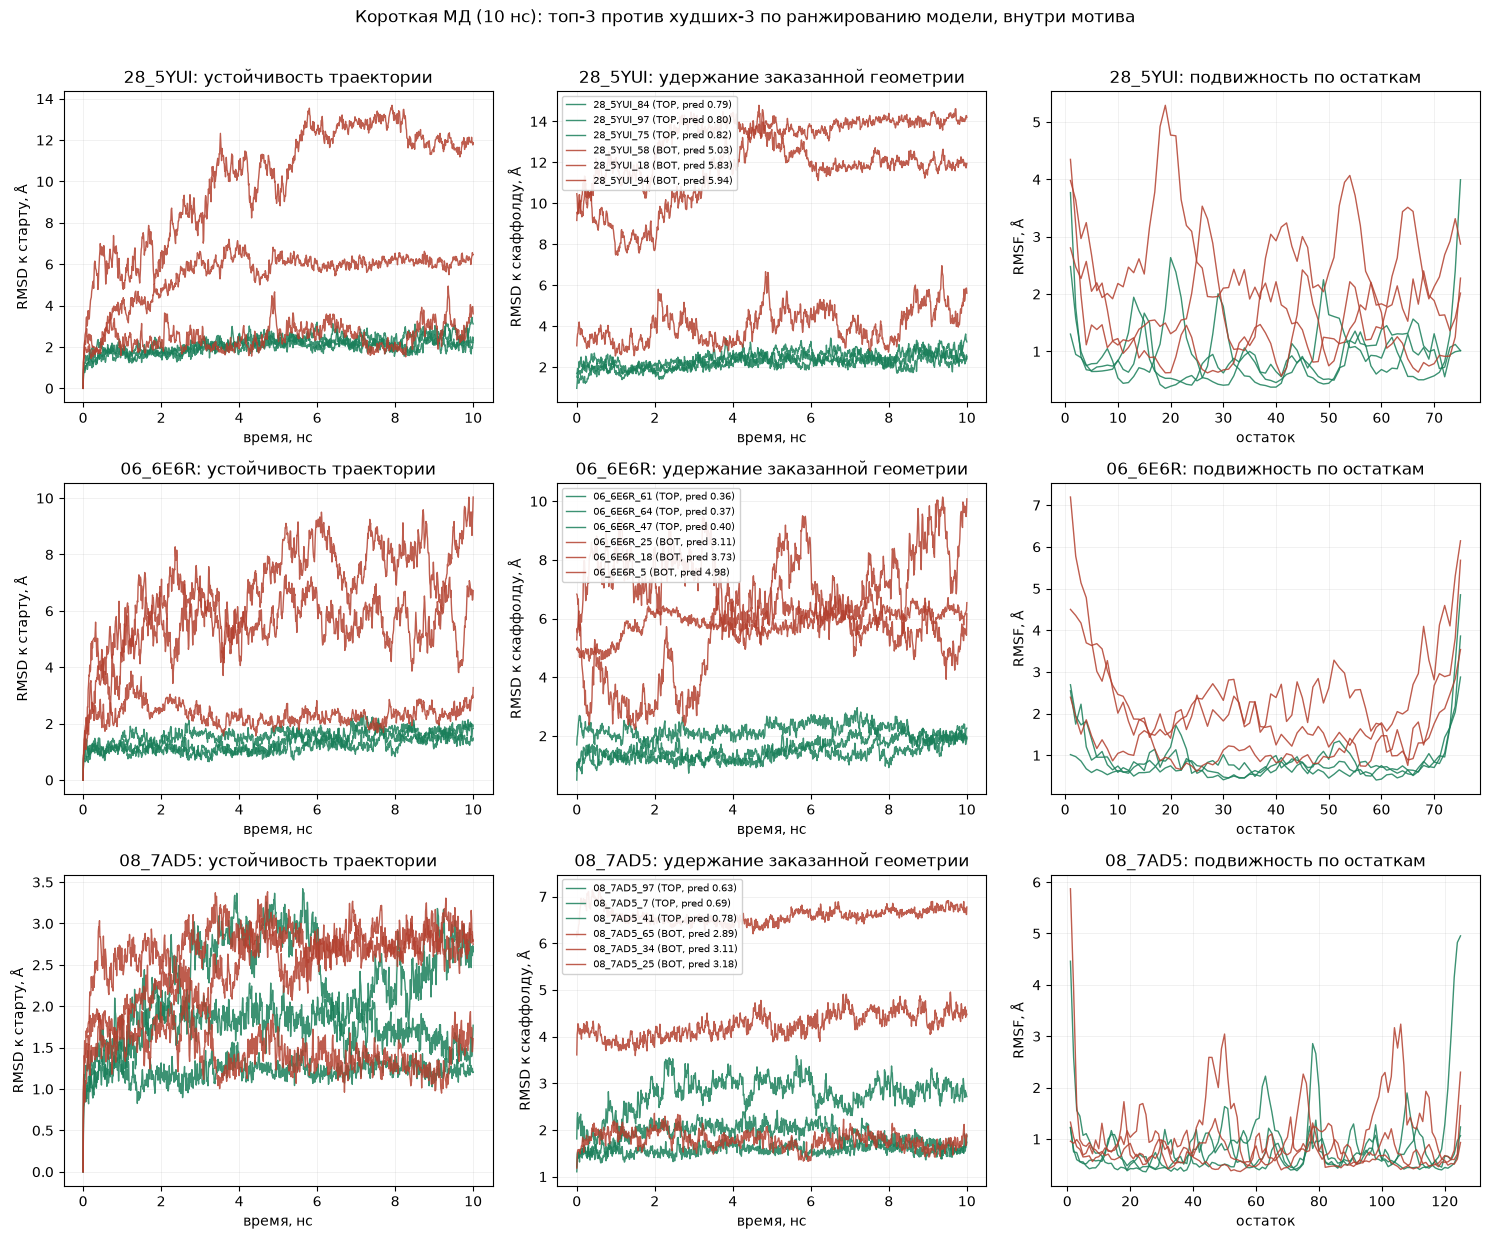

In [11]:
motifs = list(dict.fromkeys(d.motif))
fig, axes = plt.subplots(len(motifs), 3, figsize=(15, 4.2 * len(motifs)))
axes = np.atleast_2d(axes)

for row, motif in enumerate(motifs):
    for _, r in d[d.motif == motif].iterrows():
        z = series[f"{r['motif']}/{r['group']}_{r['sample']}"]
        t, c = z["time_ps"] / 1000.0, COLOR[r["group"]]
        axes[row, 0].plot(t, z["rmsd_start"], c=c, lw=1.0, alpha=0.85)
        axes[row, 1].plot(t, z["rmsd_scaf"], c=c, lw=1.0, alpha=0.85,
                          label=f"{r['sample']} ({r['group']}, pred {r['pred_scrmsd']:.2f})")
        axes[row, 2].plot(np.arange(1, len(z["rmsf"]) + 1), z["rmsf"], c=c, lw=1.0, alpha=0.85)
    axes[row, 0].set(xlabel="время, нс", ylabel="RMSD к старту, Å",
                     title=f"{motif}: устойчивость траектории")
    axes[row, 1].set(xlabel="время, нс", ylabel="RMSD к скаффолду, Å",
                     title=f"{motif}: удержание заказанной геометрии")
    axes[row, 2].set(xlabel="остаток", ylabel="RMSF, Å",
                     title=f"{motif}: подвижность по остаткам")
    axes[row, 1].legend(fontsize=7, loc="upper left", framealpha=0.9)
    for ax in axes[row]:
        ax.grid(alpha=0.25, lw=0.5)

fig.suptitle("Короткая МД (10 нс): топ-3 против худших-3 по ранжированию модели, "
             "внутри мотива", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97))
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/md_stability.png", dpi=150)
plt.show()

Два верхних мотива — in-sample, зелёное и красное расходятся сразу и не смешиваются.
Нижний (`08_7AD5`) — отложенный, и там картина совсем другая: кривые переплетены.
Разберём по очереди.

## 5. Значимость

Дизайн — 3 против 3 внутри мотива, поэтому применим точный перестановочный тест
со стратификацией по мотивам: $\binom{6}{3}^n$ раскладок, минимально достижимый
односторонний $p$ равен $1/20^n$. Для двух мотивов это 0.0025, для трёх — 0.000125.
Важно помнить: когда тест выдаёт ровно это число, он говорит «разделение идеальное»,
а не «эффект огромен».

In [12]:
def separated(sub, col):
    t, b = sub[sub.group == "TOP"][col], sub[sub.group == "BOT"][col]
    return t.max() < b.min() or t.min() > b.max()


def perm_test(df, col, motifs):
    """Точный стратифицированный перестановочный тест."""
    arrs = [df[df.motif == m][col].values for m in motifs]
    obs = sum(df[(df.motif == m) & (df.group == "TOP")][col].mean()
              - df[(df.motif == m) & (df.group == "BOT")][col].mean() for m in motifs)
    per = []
    for combo in itertools.product(itertools.combinations(range(6), 3), repeat=len(motifs)):
        s = 0.0
        for a, idx in zip(arrs, combo):
            m_ = np.zeros(6, bool)
            m_[list(idx)] = True
            s += a[m_].mean() - a[~m_].mean()
        per.append(s)
    per = np.array(per)
    return obs, min((per <= obs).mean(), (per >= obs).mean())


res = []
for col in M:
    obs, p = perm_test(d, col, motifs)
    res.append({"метрика": col, "TOP-BOT": round(obs, 2), "p": round(p, 5),
                **{m: ("да" if separated(d[d.motif == m], col) else "нет") for m in motifs}})
print(pd.DataFrame(res).to_string(index=False))

        метрика  TOP-BOT       p 28_5YUI 06_6E6R 08_7AD5
rmsd_start_mean    -9.03 0.00188      да      да     нет
 rmsd_scaf_mean   -14.42 0.00038      да      да     нет
        rg_mean    -6.36 0.00150      да      да     нет
      rmsf_mean    -2.23 0.00050      да      да     нет
 sse_frac_start     0.25 0.01550      да     нет      да
     hbond_mean    52.23 0.00012      да      да      да


Читать эту таблицу нужно по столбцам мотивов, а не по $p$. Малое $p$ здесь набирается
за счёт двух in-sample мотивов; вопрос в том, какие метрики держатся **везде**.

Держится одна — число внутрибелковых водородных связей. Абсолютные значения между
мотивами несопоставимы (у 125-остаточного мотива их около 112, у 75-остаточных около 72),
сравнивать можно только внутри мотива, но там она работает во всех трёх случаях.
Правдоподобное объяснение: плотность H-сетки меряет качество упаковки напрямую и меньше
зависит от того, каким именно способом разваливается конкретная неудачная укладка.

Геометрические метрики — RMSD, RMSF, радиус инерции — идеально делят оба in-sample мотива
и не делят отложенный.

In [13]:
print("=== ранговая корреляция внутри мотива (n=6 на мотив) ===")
for m, g in d.groupby("motif", sort=False):
    print(f"-- {m} --")
    for col in ["rmsd_start_mean", "rmsd_scaf_mean", "rmsf_mean", "rg_mean"]:
        r1, _ = spearmanr(g.pred_scrmsd, g[col])
        r2, _ = spearmanr(g.sc_rmsd_true, g[col])
        print(f"  {col:16s} rho(предсказание)={r1:5.2f}   rho(истинный scRMSD)={r2:5.2f}")

=== ранговая корреляция внутри мотива (n=6 на мотив) ===
-- 28_5YUI --
  rmsd_start_mean  rho(предсказание)= 0.77   rho(истинный scRMSD)= 0.77
  rmsd_scaf_mean   rho(предсказание)= 0.77   rho(истинный scRMSD)= 0.94
  rmsf_mean        rho(предсказание)= 0.77   rho(истинный scRMSD)= 0.60
  rg_mean          rho(предсказание)= 0.77   rho(истинный scRMSD)= 0.60
-- 06_6E6R --
  rmsd_start_mean  rho(предсказание)= 0.66   rho(истинный scRMSD)= 1.00
  rmsd_scaf_mean   rho(предсказание)= 0.66   rho(истинный scRMSD)= 0.83
  rmsf_mean        rho(предсказание)= 0.71   rho(истинный scRMSD)= 0.89
  rg_mean          rho(предсказание)= 0.71   rho(истинный scRMSD)= 0.89
-- 08_7AD5 --
  rmsd_start_mean  rho(предсказание)= 0.71   rho(истинный scRMSD)= 0.83
  rmsd_scaf_mean   rho(предсказание)= 0.71   rho(истинный scRMSD)= 0.83
  rmsf_mean        rho(предсказание)= 0.66   rho(истинный scRMSD)= 0.77
  rg_mean          rho(предсказание)= 0.03   rho(истинный scRMSD)=-0.03


Ранжирование модели коррелирует с поведением в силовом поле во всех трёх мотивах, включая
отложенный ($\rho = 0.66$–$0.77$). При $n = 6$ значимости тут нет, это направление, а не
вывод. Любопытная деталь: в `28_5YUI` предсказание согласуется с динамикой **лучше**, чем
истинный scRMSD, на котором модель обучалась. По одному мотиву утверждать нельзя, но
гипотеза «модель видит то, чего один рефолд ESMFold не измеряет» заслуживает проверки.

## 6. Перенос на отложенный мотив

`28_5YUI` и `06_6E6R` модель видела при дообучении. `08_7AD5` — нет. Это единственная
часть эксперимента, которая говорит что-то о переносе.

In [14]:
v = d[d.motif == "08_7AD5"]
print(v[show].round(2).to_string(index=False))
print()
print(v.groupby("group")[M].mean().round(2).to_string())
print()
print("разделение диапазонов и p (20 раскладок, пол 0.05):")
for col in M:
    t, b = v[v.group == "TOP"][col], v[v.group == "BOT"][col]
    _, p = perm_test(v, col, ["08_7AD5"])
    flag = "ДА " if separated(v, col) else "нет"
    print(f"  {col:16s} TOP [{t.min():6.2f},{t.max():6.2f}]  "
          f"BOT [{b.min():6.2f},{b.max():6.2f}]  разделены: {flag}  p={p:.3f}")

  motif     sample group  pred_scrmsd  sc_rmsd_true  designable  rmsd_start_mean  rmsd_scaf_mean  rmsd_scaf_t0  rg_mean  rmsf_mean  sse_frac_start  hbond_mean
08_7AD5 08_7AD5_97   TOP         0.63          0.76        True             1.71            1.87          1.21    15.27       0.72            0.63      112.29
08_7AD5  08_7AD5_7   TOP         0.69          0.82        True             1.24            1.59          1.10    14.48       0.61            0.61      112.39
08_7AD5 08_7AD5_41   TOP         0.78          1.26        True             2.46            2.84          1.81    14.86       0.99            0.67      115.38
08_7AD5 08_7AD5_65   BOT         2.89          0.87        True             1.35            1.72          1.18    15.26       0.77            0.58       97.59
08_7AD5 08_7AD5_34   BOT         3.11          2.57       False             2.72            4.40          3.61    15.39       1.02            0.49       92.84
08_7AD5 08_7AD5_25   BOT         3.18         

**Идеальное разделение не воспроизвелось.** Четыре геометрические метрики здесь
перекрываются, работают только доля вторичной структуры и H-связи, обе на пределе
$p = 0.05$.

Причина — одна система, и это настоящая ошибка модели. `08_7AD5_65` отправлен в худшую
тройку (pred 2.89), а истинный scRMSD 0.87 Å: он уверенно дизайнируем. В динамике он
ведёт себя как TOP по всем показателям. То есть МД встала на сторону разметки, а не
модели — это **ложный отказ**, а не увиденная моделью нестабильность, которую пропустил
ESMFold. На двух in-sample мотивах такого не было: там все шесть отбракованных были
недизайнируемы и по разметке.

Проверим, что без него разделение восстанавливается.

In [15]:
v2 = v[v["sample"] != "08_7AD5_65"]
for col in ["rmsd_scaf_mean", "rmsd_start_mean", "rmsf_mean"]:
    t, b = v2[v2.group == "TOP"][col], v2[v2.group == "BOT"][col]
    print(f"  {col:16s} TOP [{t.min():.2f},{t.max():.2f}]  BOT [{b.min():.2f},{b.max():.2f}]  "
          f"разделены: {'ДА' if t.max() < b.min() else 'нет'}")

  rmsd_scaf_mean   TOP [1.59,2.84]  BOT [4.40,6.65]  разделены: ДА
  rmsd_start_mean  TOP [1.24,2.46]  BOT [2.72,2.79]  разделены: ДА
  rmsf_mean        TOP [0.61,0.99]  BOT [0.91,1.02]  разделены: нет


Восстанавливается. Значит перекрытие в этом мотиве — не размытый сигнал, а один
конкретный промах.

## 7. Направление ошибки

Для префильтра важно не только сколько ошибок, но и в какую сторону.

In [16]:
top, bot = d[d.group == "TOP"], d[d.group == "BOT"]
print(f"отобранных систем: {len(top)}, из них дизайнируемых по разметке: {top.designable.sum()}")
print(f"  RMSD к скаффолду на топе: {top.rmsd_scaf_mean.min():.2f}-{top.rmsd_scaf_mean.max():.2f} Å")
print(f"отбракованных: {len(bot)}, из них дизайнируемых (ложный отказ): "
      f"{bot.designable.sum()} -> {list(bot[bot.designable]['sample'])}")

отобранных систем: 9, из них дизайнируемых по разметке: 9
  RMSD к скаффолду на топе: 1.53-2.84 Å
отбракованных: 9, из них дизайнируемых (ложный отказ): 1 -> ['08_7AD5_65']


Девять из девяти отобранных дизайнируемы, RMSD к скаффолду 1.53–2.84 Å — промахов на топе
нет ни одного. Единственная ошибка на всём эксперименте — ложный отказ.

Для префильтра это дешёвая сторона: ложный отказ стоит одного пропущенного кандидата,
ложное принятие — дорогой проверки ESMFold и всего, что за ней. Точность на топе, ради
которой фильтр и строится, не пострадала.

## 8. Что из этого следует

1. **Ранжирование модели предсказывает поведение в силовом поле.** На in-sample мотивах
   отобранные держатся в 1.45–2.50 Å от старта, отбракованные разбросаны шире и в среднем
   много дальше (2.29–12.19 Å при средних по группам 6.99 и 5.36 против 2.27 и 1.54),
   средняя подвижность отличается вдвое-втрое. Это независимое от ESMFold подтверждение: сигнал, извлечённый
   из одного остова, воспроизводится физикой.

2. **Но масштаб эффекта завышен in-sample мотивами.** На отложенном мотиве разделение
   держится только на H-связях и доле вторичной структуры, геометрия перекрывается.
   Осторожная формулировка: на in-sample мотивах разделение выглядело идеальным отчасти
   потому, что мотивы были in-sample.

3. **Компактность — ненадёжный признак.** На двух мотивах радиус инерции разделял группы
   без перекрытия внутри мотива и напрашивался в «самые чистые разделители»
   (объединять мотивы в один диапазон нельзя: шкала Rg зависит от длины цепи). На третьем $\rho = 0.03$.
   Это был артефакт выборки.

4. **H-связи — единственный признак, работающий везде.** Внутри мотива, поскольку
   абсолютные значения зависят от длины цепи.

5. **Локальная структура и укладка расходятся.** В `06_6E6R` доля вторичной структуры у
   отбракованных даже выше (0.85 против 0.83) — спирали и листы на месте, разваливается
   их взаимное расположение. В `28_5YUI` рушится и локальный уровень. Отбраковка модели
   не сводится к «мало вторичной структуры».

6. **«Прирост RMSD за счёт динамики» — негодная метрика.** Идея вычесть $t_0$ и оставить
   чистый вклад МД выглядит естественной, но у `06_6E6R_18` прирост отрицательный
   (−0.94 Å): структура ушла от скаффолда на 6.8 Å ещё на старте, попала в другой минимум,
   и дальше RMSD к скаффолду блуждает без направления. Вычитание $t_0$ осмысленно, только
   пока стартовая ошибка мала.

## 9. Оговорки

* **Отбор с краёв.** Сравнивались хвосты — топ-3 и худшие-3 из 100. Это измеряет
  способность различать крайности, а не калибровку на всём диапазоне.
* **18 систем, по одной реплике.** Ни одна система не считалась повторно с другой затравкой
  скоростей, поэтому неизвестно, какая доля разброса внутри группы — структура,
  а какая — случайность траектории.
* **10 нс — коротко.** Масштаб, на котором ловят грубую нестабильность, а не сворачивание.
  Отсутствие развала за 10 нс не означает, что структура стабильна.
* **Один отложенный мотив из шести.** `23_1MPY` (0.72, длина 125) — очевидный следующий
  кандидат.
* **Не эксперимент.** Силовое поле независимо от ESMFold, но это по-прежнему вычислительная
  оценка (docs/07, раздел 7.6).
* **Стартовая структура — рефолд, а не сам скаффолд.** Всё сказанное относится к паре
  «скаффолд + лучшая последовательность ProteinMPNN», и часть различий между группами
  может относиться к качеству дизайна последовательности, а не остова.